In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as mp
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [2]:
df = pd.read_csv("/content/Housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.shape

(545, 13)

In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode(numeric_only=True)
df.var(numeric_only=True)
df.std(numeric_only=True)

,0
price,1.870440e+06
area,2.170141e+03
bedrooms,7.380639e-01
bathrooms,5.024696e-01
stories,8.674925e-01
parking,8.615858e-01


In [9]:
df.skew(numeric_only=True)

,0
price,1.212239
area,1.321188
bedrooms,0.495684
bathrooms,1.589264
stories,1.082088
parking,0.842062


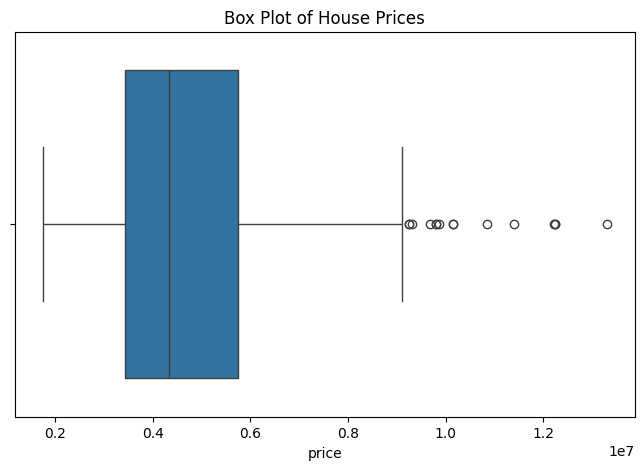

In [10]:
mp.figure(figsize=(8,5))

sb.boxplot(x=df["price"])

mp.title("Box Plot of House Prices")

mp.show()

In [11]:
Q1 = df["price"].quantile(0.25)

Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [12]:
outliers = df[(df["price"] < lower) | (df["price"] > upper)]

outliers

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [13]:
df.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


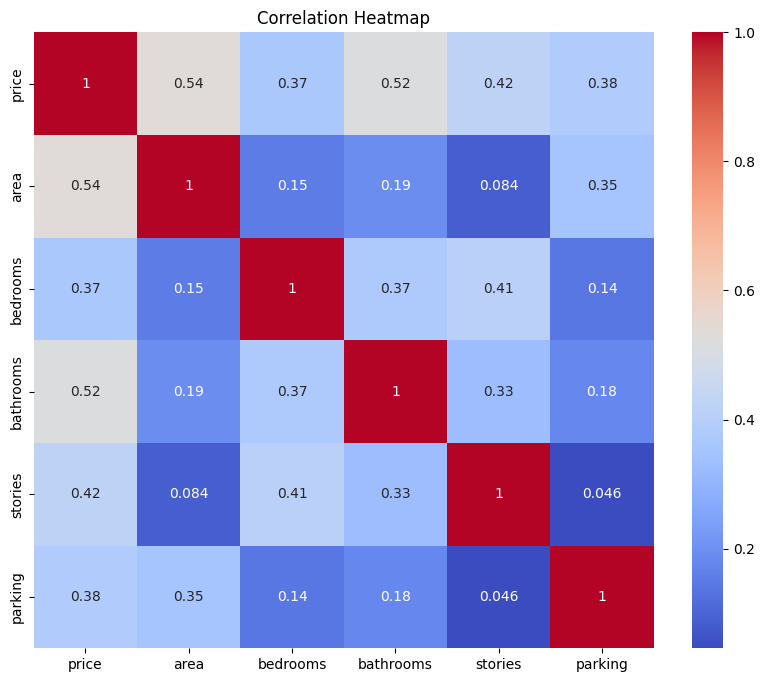

In [14]:
mp.figure(figsize=(10,8))

sb.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

mp.title("Correlation Heatmap")

mp.show()

In [15]:
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

corr

,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


In [16]:
corr.head(6)

,price
price,1.000000
area,0.535997
bathrooms,0.517545
stories,0.420712
parking,0.384394
bedrooms,0.366494


In [17]:
df.select_dtypes(include="object").columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [19]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [21]:
X = df[["area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:
slr = LinearRegression()

slr.fit(X_train, y_train)

LinearRegression()

In [23]:
slr_pred = slr.predict(X_test)

In [24]:
X = df.drop("price", axis=1)

y = df["price"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
mlr = LinearRegression()

mlr.fit(X_train, y_train)

LinearRegression()

In [27]:
mlr_pred = mlr.predict(X_test)

In [28]:
slr_rmse = np.sqrt(mean_squared_error(y_test, slr.predict(X_test[["area"]])))


slr_r2 = r2_score(y_test, slr.predict(X_test[["area"]]))

print("Simple Linear Regression")

print("RMSE :", slr_rmse)

print("R² Score :", slr_r2)

Simple Linear Regression
RMSE : 1917103.7021424233
R² Score : 0.27287851871974644


In [29]:
mlr_rmse = np.sqrt(mean_squared_error(y_test, mlr_pred))

mlr_r2 = r2_score(y_test, mlr_pred)

print("Multiple Linear Regression")

print("RMSE :", mlr_rmse)

print("R² Score :", mlr_r2)

Multiple Linear Regression
RMSE : 1331071.4167895108
R² Score : 0.6494754192267803


In [30]:
comparison = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "RMSE": [slr_rmse, mlr_rmse],
    "R2 Score": [slr_r2, mlr_r2]
})

comparison

,Model,RMSE,R2 Score
0,Simple Linear Regression,1.917104e+06,0.272879
1,Multiple Linear Regression,1.331071e+06,0.649475


In [31]:
unseen_houses = X_test.head(10)

predictions = mlr.predict(unseen_houses)

result = unseen_houses.copy()

result["Predicted Price"] = predictions

result

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,Predicted Price
316,5900,4,2,2,0,0,1,0,0,1,0,2,5.203692e+06
77,6500,3,2,3,1,0,0,0,1,0,1,0,7.257004e+06
360,4040,2,1,1,1,0,0,0,0,0,0,1,3.062829e+06
90,5000,3,1,2,1,0,0,0,1,0,0,1,4.559592e+06
493,3960,3,1,1,1,0,0,0,0,0,0,0,3.332932e+06
209,6720,3,1,1,1,0,0,0,0,0,0,2,3.563081e+06
176,8520,3,1,1,1,0,0,0,1,2,0,0,5.645466e+06
249,4990,4,2,2,1,1,1,0,0,0,1,0,6.413980e+06
516,3240,2,1,1,0,1,0,0,0,1,0,2,2.755832e+06
426,2700,3,1,1,0,0,0,0,0,0,0,0,2.668939e+06


In [32]:
joblib.dump(mlr, "House_Price_Model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
